# 10 · Budget allocation and incremental response
**Part A — iFood (real cost & revenue parameters, back-tested on actual pilot outcomes).** With a fixed budget
(3 MU per contact), which customers should be contacted? Method: rank-and-cut + marginal-return analysis — the simplest
method that answers the question (there is one channel and one cost per contact, so linear programming would add nothing).

**Part B — Hillstrom (randomised).** Which campaign type should be sent to whom, and does personalising beat
'best campaign for everyone'? This is the only place the project makes causal statements.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
from src import pipeline as P
from src.config import *

[19:43:49] budget allocation


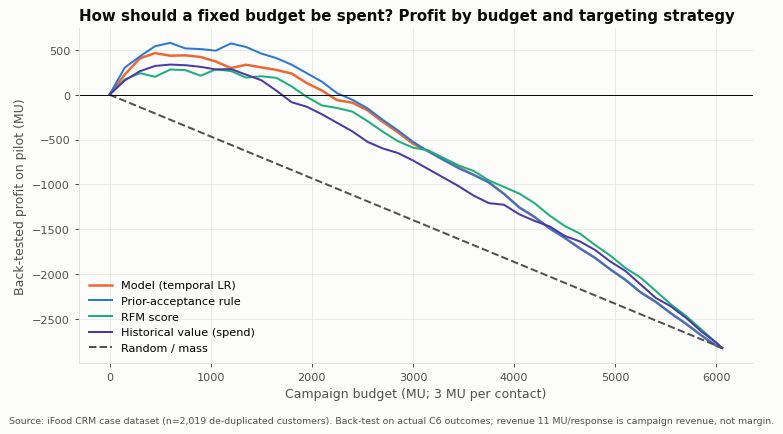

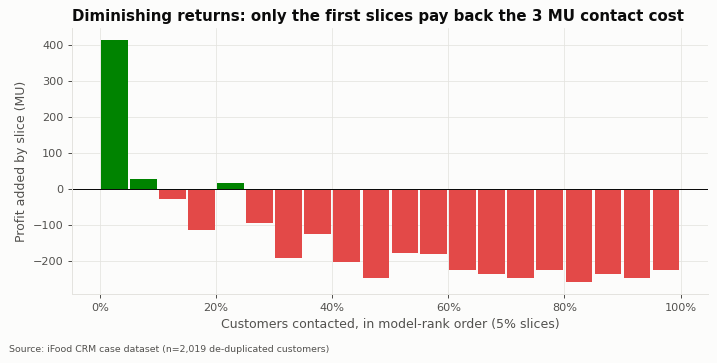

,scenario,rule,contacts,budget_used_mu,responses,response_rate,profit_mu,share_of_all_responders_captured
0,A Mass contact (what the pilot did),contact every customer,2019,"6,057",294,0.1456,"-2,823",1
1,B Historical-responder rule,contact customers who accepted >=1 of C1-C5,417,"1,251",168,0.4029,597,0.5714
2,C RFM top 20%,highest R+F+M scores,404,"1,212",135,0.3342,273,0.4592
3,D Value-focused top 20%,highest 2-yr spend,404,"1,212",136,0.3366,284,0.4626
4,E Model top 20%,highest predicted response (temporal LR),404,"1,212",137,0.3391,295,0.466
5,F Model ex-ante break-even rule,contact if model p >= 0.273 (model calibrated to C2-C5 base rates),140,420,81,0.5786,471,0.2755


In [2]:
ctx = P.prepare('stage_optimization')
ctx = P.stage_optimization(ctx)
ctx['scenarios']

> **Finding:** Contacting only the 417 customers who accepted an earlier campaign would have turned the pilot's −2,823 MU into +597 MU while keeping 57 % of responders. The model's top 20 % earns +295 MU (bootstrap 95 % CI 97 to 526); mass contact loses money in 8 of 9 cost/revenue scenarios.
>
> **Business implication:** The audience should be cut to roughly a fifth to a quarter of the base (the earlier acceptors) — more coverage buys responses at a loss.
>
> **Recommended action:** Budget ≈ 1,250 MU (417 contacts) for the next campaign; if the budget is smaller, fill it in P1 model order.
>
> **Evidence:** Scenario back-test, bootstrap CIs, marginal returns.
>
> **Assumption:** Next campaign ≈ pilot economics and response behaviour.
>
> **Limitation:** Back-tests on the same campaign used to design the tiers are optimistic; a randomised holdout should confirm.

In [3]:
ctx['profit_boot']

,contact_share,profit_mean,profit_ci_low,profit_ci_high,p_profit_positive
0,0.05,398.2,291,500,1
1,0.1,444,285,626,1
2,0.15,409.8,213,620,1
3,0.2,310.5,97,526,0.999
4,0.3,206.5,-36.27,470,0.946
5,0.5,-548.8,-830,-268.7,0
6,1,"-2,826","-3,175","-2,471",0


In [4]:
ctx['marginal']

,from_share,to_share,contacts,responses,response_rate,marginal_profit_mu
0,0,0.05002,101,65,0.6436,412
1,0.05002,0.1,101,30,0.297,27
2,0.1,0.1501,101,25,0.2475,-28
3,0.1501,0.2001,101,17,0.1683,-116
4,0.2001,0.2501,101,29,0.2871,16
5,0.2501,0.3001,101,19,0.1881,-94
6,0.3001,0.3502,101,10,0.09901,-193
7,0.3502,0.4002,101,16,0.1584,-127
8,0.4002,0.4502,101,9,0.08911,-204
9,0.4502,0.5002,101,5,0.0495,-248


In [5]:
ctx['econ_sens']

,cost_per_contact,revenue_per_response,break_even_p,hindsight_best_contacts,hindsight_best_share,hindsight_best_profit,profit_contact_all,profit_top20pct
0,2,8,0.25,240,0.1189,376,"-1,686",282
1,2,11,0.1818,596,0.2952,843,-804,690
2,2,14,0.1429,596,0.2952,"1,398",78,"1,098"
3,3,8,0.375,126,0.06241,238,"-3,705",-121
4,3,11,0.2727,161,0.07974,474,"-2,823",287
5,3,14,0.2143,506,0.2506,820,"-1,941",695
6,4,8,0.5,101,0.05002,116,"-5,724",-524
7,4,11,0.3636,126,0.06241,343,"-4,842",-116
8,4,14,0.2857,129,0.06389,576,"-3,960",292


The profit-optimal contact share is **sensitive** to the economics (5 %–30 % of customers across cost 2–4 and revenue 8–14 MU): diminishing returns are observed in the ranked back-test, but where to stop depends on assumptions.

In [6]:
ctx['forward_plan']

,budget_mu,contacts,expected_responses,expected_profit_mu,customers_with_positive_expected_profit_in_selection,label
0,600,200,132.1,852.9,200,MODEL-EXPECTED under assumption next campaign ~ pilot (not an observed outcome)
1,1200,400,190.7,898,311,MODEL-EXPECTED under assumption next campaign ~ pilot (not an observed outcome)
2,1800,600,222,642.5,319,MODEL-EXPECTED under assumption next campaign ~ pilot (not an observed outcome)
3,2400,800,244.6,291,319,MODEL-EXPECTED under assumption next campaign ~ pilot (not an observed outcome)
4,3000,1000,259.5,-145.5,319,MODEL-EXPECTED under assumption next campaign ~ pilot (not an observed outcome)
5,6000,2000,293.9,"-2,768",319,MODEL-EXPECTED under assumption next campaign ~ pilot (not an observed outcome)


⚠️ **Forward plan = model-expected values under the assumption that the next campaign behaves like the pilot. They are not observed outcomes and are optimistic relative to the back-test.**

## Part B — incremental response (Hillstrom randomised experiment)

[19:43:52] incremental response (Hillstrom experiment)


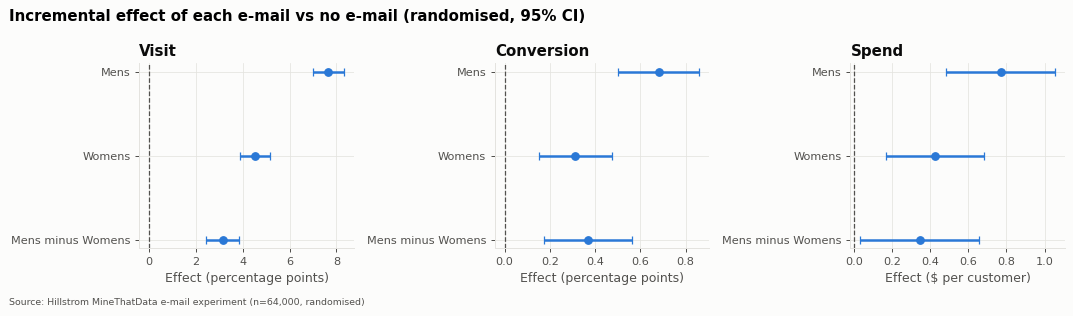

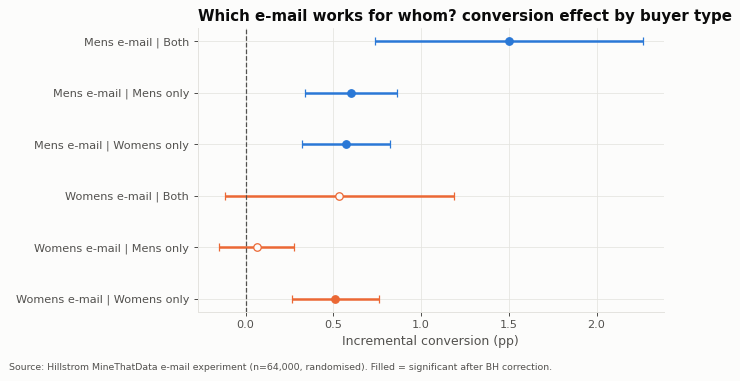

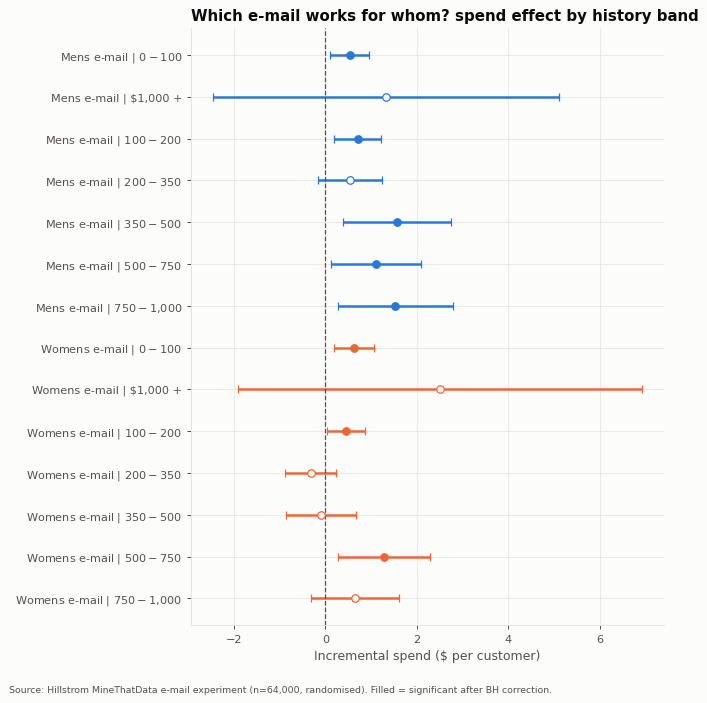

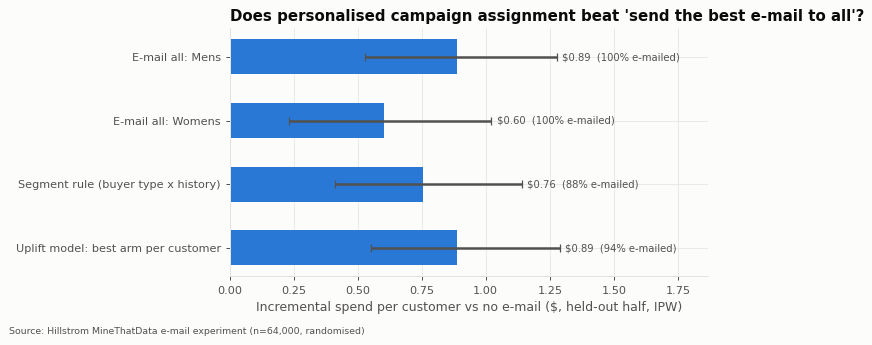

,treatment,customers,visit_rate,conversion_rate,spend_per_customer,spend_per_converter,conv_ci_low,conv_ci_high
0,Control,21306,0.1062,0.005726,0.6528,114,0.004798,0.006832
1,Mens,21307,0.1828,0.01253,1.423,113.5,0.01112,0.01412
2,Womens,21387,0.1514,0.008837,1.077,121.9,0.007668,0.01018


In [7]:
ctx = P.stage_uplift(ctx)
u = ctx['uplift']
u['arm_summary']

In [8]:
u['ate']

,arm,outcome,n_treated,n_control,control_mean,treated_mean,effect,ci_low,ci_high,p_value,relative_lift,p_holm
0,Mens,visit,21307,21306,0.1062,0.1828,0.07659,0.06995,0.08323,0,0.7214,0
1,Mens,conversion,21307,21306,0.005726,0.01253,0.006805,0.005,0.00861,1.523e-13,1.188,9.139e-13
2,Mens,spend,21307,21306,0.6528,1.423,0.7698,0.4851,1.055,1.164e-07,1.179,5.819e-07
3,Womens,visit,21387,21306,0.1062,0.1514,0.04523,0.03889,0.05157,0,0.4261,0
4,Womens,conversion,21387,21306,0.005726,0.008837,0.003111,0.001499,0.004723,0.0001571,0.5433,0.0006284
5,Womens,spend,21387,21306,0.6528,1.077,0.4244,0.169,0.6799,0.001129,0.6502,0.002259
6,Mens minus Womens,visit,21307,21387,0.1514,0.1828,0.03136,0.02429,0.03843,0,0.2071,0
7,Mens minus Womens,conversion,21307,21387,0.008837,0.01253,0.003694,0.001744,0.005644,0.0002052,0.418,0.0006284
8,Mens minus Womens,spend,21307,21387,1.077,1.423,0.3454,0.03257,0.6583,0.03047,0.3207,0.03047


> **Finding:** Both e-mails cause more visits, conversions and spend. Mens e-mail: +0.68 pp conversion, +$0.77 spend per customer (95 % CI 0.49–1.05); Womens: +0.31 pp, +$0.42 (0.17–0.68). Mens beats Womens by $0.35 per customer (Holm p = 0.03; 98 % of bootstrap resamples).
>
> **Business implication:** If only one campaign can be sent, the Mens-merchandise e-mail generates more incremental revenue overall. By buyer type: for womens-only buyers both e-mails work equally (+$0.62 vs +$0.63); for mens-only buyers only the Mens e-mail shows an effect (Womens: +0.06 pp conversion, CI includes 0) — suggestive, but heterogeneity is not significant after BH.
>
> **Recommended action:** Default campaign type: Mens e-mail.
>
> **Evidence:** Randomised arms, ~21,300 customers each, balance SMD < 0.02.
>
> **Assumption:** No interference between customers; 2-week window captures the effect.
>
> **Limitation:** Spend is revenue, not margin; e-mail cost is not in the data.

In [9]:
u['heterogeneity']

,dimension,arm,outcome,levels,Q,df,p_value,effect_min,effect_max,p_bh
0,buyer_type,Mens,conversion,3,5.232,2,0.07311,0.005722,0.01499,0.2924
1,buyer_type,Mens,spend,3,2.955,2,0.2282,0.6157,1.825,0.4979
2,buyer_type,Womens,conversion,3,7.846,2,0.01978,0.0006327,0.00533,0.1582
3,buyer_type,Womens,spend,3,2.142,2,0.3427,0.1619,0.6316,0.5484
4,channel,Mens,conversion,3,2.323,2,0.3131,0.005462,0.01017,0.5484
5,channel,Mens,spend,3,2.216,2,0.3302,0.5641,1.209,0.5484
6,channel,Womens,conversion,3,3.388,2,0.1838,0.001726,0.007052,0.4979
7,channel,Womens,spend,3,3.585,2,0.1666,0.2325,1.158,0.4979
8,history_band,Mens,conversion,7,7.649,6,0.2649,0.004818,0.02002,0.5299
9,history_band,Mens,spend,7,5.255,6,0.5115,0.5366,1.569,0.6916


In [10]:
u['qini_table']

,outcome,arm,ranking,qini_coefficient,random_mean,random_p2_5,random_p97_5,beats_random_95,total_incremental_in_arm
0,conversion,Mens,uplift (T-learner),-1.231,0.5286,-7.214,7.063,False,77.99
1,conversion,Mens,response model P(y|email),3.165,0.5286,-7.214,7.063,False,77.99
2,conversion,Womens,uplift (T-learner),3.232,-0.7783,-8.138,6.032,False,37.77
3,conversion,Womens,response model P(y|email),2.638,-0.7783,-8.138,6.032,False,37.77
4,visit,Mens,uplift (T-learner),34.78,1.466,-31.31,27.52,True,805.9
5,visit,Mens,response model P(y|email),44.99,1.466,-31.31,27.52,True,805.9
6,visit,Womens,uplift (T-learner),84.46,1.013,-25.12,27.4,True,529.8
7,visit,Womens,response model P(y|email),51.27,1.013,-25.12,27.4,True,529.8


In [11]:
u['policies']

,policy,spend_per_customer,conversion_rate,emails_per_customer,incremental_spend_per_customer,incremental_spend_per_email,inc_spend_ci_low,inc_spend_ci_high
0,No e-mail,0.5939,0.005726,0,0,NaN,0,0
1,E-mail all: Mens,1.481,0.01305,1,0.8875,0.8875,0.5281,1.277
2,E-mail all: Womens,1.197,0.009258,1,0.603,0.603,0.2309,1.022
3,Segment rule (buyer type x history),1.349,0.01144,0.8769,0.7551,0.8611,0.4129,1.142
4,Uplift model: best arm per customer,1.482,0.01181,0.9416,0.8883,0.9434,0.5502,1.289


> **Finding:** No subgroup heterogeneity survives BH correction; the per-customer uplift model's policy (+$0.888/customer) equals 'Mens e-mail to everyone' (+$0.888). For the rare conversion outcome no ranking beats random on Qini; for visits, uplift ranking beats response ranking for the Womens e-mail (Qini 84 vs 51).
>
> **Business implication:** Predicted response ≠ incremental response: the people most likely to act are not always those the e-mail moves. But at this data size, personalising the campaign type does not pay.
>
> **Recommended action:** Send the single best campaign rather than a personalised assignment; use uplift modelling only for high-frequency outcomes (visits) or larger samples.
>
> **Evidence:** Cochran's Q tests (BH), Qini vs 100 random rankings, IPW policy values on a held-out half with bootstrap CIs.
>
> **Assumption:** Held-out half is representative.
>
> **Limitation:** One 2008 experiment from another retailer; e-mail cost unknown — see the HYPOTHETICAL cost scenarios table.

In [12]:
import pandas as pd
pd.read_csv(TAB/'hillstrom_email_cost_scenarios_HYPOTHETICAL.csv').pivot(index='policy', columns='assumed_cost_per_email', values='net_incremental_per_1000_customers').round(0)

assumed_cost_per_email,0.0,0.05,0.1,0.25,0.5,1.0
policy,,,,,,
E-mail all: Mens,888,838,788,638,388,-112
E-mail all: Womens,603,553,503,353,103,-397
No e-mail,0,0,0,0,0,0
Segment rule (buyer type x history),755,711,667,536,317,-122
Uplift model: best arm per customer,888,841,794,653,417,-53


### Predictive vs incremental — what applies to iFood
The iFood data are observational: nobody was randomly withheld from any campaign. **The observational dataset supports
response prediction but does not reliably identify incremental treatment effects.** The iFood targeting engine therefore
predicts *who responds*, not *who responds because of the offer*. The recommended validation is to keep a random 10–20 %
holdout inside P1 in the next campaign.